In [70]:
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict, Annotated

from dotenv import load_dotenv

from pydantic import BaseModel, Field
import operator

In [71]:
load_dotenv()

True

In [72]:
model = ChatGoogleGenerativeAI(
    model="gemini-3.6-flash",
    temperature=0
)

In [73]:
#defining LLM output structure 
class EvalulationSchema(BaseModel):
    feadback: str = Field(description='Derailed feadback for the eassy')
    score: int = Field(description= 'Score out of 10', ge=0, le=10)

In [74]:
structured_model = model.with_structured_output(EvalulationSchema)

In [ ]:
essay = """
Education is one of the most valuable tools for personal and social development. It helps people gain knowledge, develop critical thinking skills, and make informed decisions. An educated person is better prepared to face challenges and contribute positively to society.
Education also creates opportunities for better careers and improves the quality of life. It teaches important values such as honesty, responsibility, and respect for others. In today's rapidly changing world, continuous learning is essential for adapting to new technologies and solving complex problems.
In conclusion, education is the foundation of a successful life and a prosperous society. By investing in education, individuals and nations can achieve long-term growth and build a brighter future for everyone.

"""



In [76]:
prompt = f'Evaluate the language quality of the following essay and provide a feedback and assign a score out of 10 \n {essay}'
structured_model.invoke(prompt).score

/Users/mdrishatsheakh/Desktop/LangGraph_Tutorial/myenv/lib/python3.13/site-packages/langchain_google_genai/chat_models.py:3120: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


9

In [77]:
# Defining the langgraph state

class EssayState(TypedDict):
    essay_text: str
    clarity_of_thoughts = str
    depth_of_analysis = str
    language_feadback: str

    summarised_feadback: str
    individual_score: Annotated[list[int], operator.add]    #reducer function
    average_score: float

In [78]:
def Clarity_of_thoughts(state: EssayState):
    prompt = f'Evaluate the clarity of thoughts of the following essay and provide a feedback and assign a score out of 10 \n {state["essay_text"]}'
    output = structured_model.invoke(prompt)
    return {'clarity_of_thoughts': output.feadback, 'individual_score': [output.score]}

In [79]:
def Depth_of_analysis(state: EssayState):
    prompt = f'Evaluate the depth of analysis of the following essay and provide a feedback and assign a score out of 10 \n {state["essay_text"]}'
    output = structured_model.invoke(prompt)
    return {'depth_of_analysis': output.feadback, 'individual_score': [output.score]}


In [80]:
def Evaluate_Language(state: EssayState):
    prompt = f'Evaluate the language quality of the following essay and provide a feedback and assign a score out of 10 \n {state["essay_text"]}'
    output = structured_model.invoke(prompt)
    return {'language_feadback': output.feadback, 'individual_score': [output.score]}

In [81]:
def Summarised_Feadback(state: EssayState):
    #summary feadback
    prompt = f'Based on the following feedbacks create a summarized feedback \n language_feadback - {state["language_feadback"]} \n depth of analysis feedback - {state["depth_of_analysis"]} \n clarity of thought feedback - {state['clarity_of_thoughts']}'
    summarised_feadback = model.invoke(prompt).content

    #average calculate
    average = sum(state["individual_score"])/len(state["individual_score"])
    return {'summarised_feadback':summarised_feadback, 'average_score':average}

In [82]:
#create graph

graph = StateGraph(EssayState)

# adding nodes to the graph
graph.add_node('Clarity_of_thoughts', Clarity_of_thoughts)
graph.add_node('Depth_of_analysis', Depth_of_analysis)
graph.add_node('Evaluate_Language', Evaluate_Language)
graph.add_node('Summarised_Feadback', Summarised_Feadback)


#adding edges to the graph
graph.add_edge(START, 'Clarity_of_thoughts')
graph.add_edge(START, 'Depth_of_analysis')
graph.add_edge(START, 'Evaluate_Language')

graph.add_edge('Clarity_of_thoughts', 'Summarised_Feadback')
graph.add_edge('Depth_of_analysis', 'Summarised_Feadback')
graph.add_edge('Evaluate_Language', 'Summarised_Feadback')

graph.add_edge('Summarised_Feadback', END)



#compiling the graph
workflow = graph.compile()



In [ ]:

# executing the g

initial_state = {'essay_text': essay}
final_state = workflow.invoke(initial_state)
print(final_state)

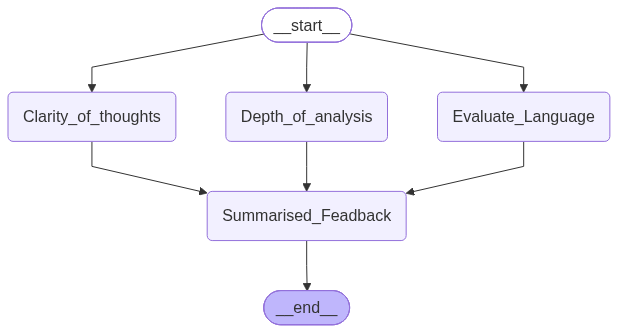

In [84]:
workflow